# Bayesian Neural Networks

**formalML — Bayesian & Probabilistic ML Track, Topic 6 (advanced, T5 flagship)**

A trained neural network gives us a function, but it does not tell us how confident to be in that function. A point-estimate classifier confidently extrapolates its decision rule into regions where no training data lives, with no way to say where the rule is wrong. Bayesian neural networks replace the single weight vector $w^*$ with a distribution $p(w \mid \mathcal{D})$ over weights and integrate predictions against it: predictive variance grows where plausible weight settings disagree, so the model knows when it doesn't know. The catch is that $p(w \mid \mathcal{D})$ is intractable in four distinct ways for any non-trivial network — no closed-form marginal likelihood, deeply non-convex log-posterior, high dimension, and full-data gradients. Each of the methods in this topic is an answer to one of those obstacles.

This notebook develops the substrate: §1 frames the geometry on a Two Moons toy classifier and previews the four-obstacle taxonomy that organizes §§3–7, §2 lifts the picture into a formal weight-space posterior with the Bernstein–von Mises asymptotic and the prior-equals-weight-decay correspondence, §3 fits the first BNN via the Laplace approximation around the MAP estimate, §4 derives MC-dropout as approximate variational inference under a Bernoulli weight family (Gal & Ghahramani 2016), §5 trains a deep ensemble as a function-space posterior proxy (Lakshminarayanan, Pritzel & Blundell 2017), §6 brings asymptotic exactness into the deep-learning regime via stochastic-gradient Langevin dynamics (Welling & Teh 2011), §7 lifts SGLD with momentum and friction to stochastic-gradient HMC (Chen, Fox & Guestrin 2014), §8 evaluates all four methods head-to-head on calibration metrics and decomposes predictive variance into epistemic and aleatoric components, and §9 closes with the function-space view from NNGP (Neal 1996; Lee et al. 2017) and the neural tangent kernel (Jacot, Gabriel & Hongler 2018) tying weight-space methods back to Gaussian processes.

**Track context.** Sixth topic of T5 Bayesian & Probabilistic ML; T5 flagship. Backward links to formalML's [Variational Inference](/topics/variational-inference) (approximate-posterior machinery reused throughout) and [Gaussian Processes](/topics/gaussian-processes) (function-space view in §9). Backward links to formalstatistics's `bayesian-foundations-and-prior-selection`, `central-limit-theorem`, `modes-of-convergence`, `multivariate-distributions`, `hierarchical-bayes-and-partial-pooling`. Forward-points to planned formalML topics on `meta-learning`, `stochastic-gradient-mcmc` (deeper SG-MCMC treatment), and `sparse-bayesian-priors`.


---


In [1]:
# Core dependencies
import os
import time
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.nn.functional as F

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Figure-export discipline: every plt.show() is preceded by plt.savefig.
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Plot styling — formalML house style
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# Color palette — recurs across figures, one color per method family
COLOR_POINT      = "#7f7f7f"  # gray   — point-estimate baseline
COLOR_LAPLACE    = "#1f77b4"  # blue   — §3 Laplace approximation
COLOR_DROPOUT    = "#2ca02c"  # green  — §4 MC-dropout
COLOR_ENSEMBLE   = "#ff7f0e"  # orange — §5 deep ensembles
COLOR_SGLD       = "#9467bd"  # purple — §6 SGLD
COLOR_SGHMC      = "#17becf"  # teal   — §7 SGHMC
COLOR_CLASS_0    = "#3b4cc0"  # blue   — Two Moons class 0
COLOR_CLASS_1    = "#b40426"  # red    — Two Moons class 1
COLOR_DATA       = "lightgray"  # gray   — data points overlaid on heatmaps
COLOR_REFERENCE  = "#000000"  # black  — reference lines

# === Shared dataset: Two Moons (used in §§1–8) ===
X, y = make_moons(n_samples=300, noise=0.20, random_state=SEED)
X = X.astype(np.float32)
y = y.astype(np.float32)
X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y).unsqueeze(1)

# === Shared MLP factory: 3 hidden layers × 32 ReLU units ===
def make_mlp(seed, hidden=32, n_hidden=3, dropout_p=0.0):
    """3-hidden-layer MLP, optional dropout (used in §4)."""
    torch.manual_seed(seed)
    layers = [nn.Linear(2, hidden), nn.ReLU()]
    if dropout_p > 0:
        layers.append(nn.Dropout(p=dropout_p))
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        if dropout_p > 0:
            layers.append(nn.Dropout(p=dropout_p))
    layers.append(nn.Linear(hidden, 1))
    return nn.Sequential(*layers)

def train_mlp(model, X_t, y_t, epochs=200, weight_decay=1e-4, lr=1e-2, verbose=False):
    """Train an MLP via Adam against BCE-with-logits + L2 weight decay."""
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for epoch in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    if verbose:
        print(f'  final loss = {losses[-1]:.4f}')
    return model, losses

# === Shared prediction grid (used in every method's heatmap) ===
xx, yy = np.meshgrid(
    np.linspace(-2.5, 2.5, 200, dtype=np.float32),
    np.linspace(-2.0, 2.0, 200, dtype=np.float32),
)
GRID = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
GRID_t = torch.from_numpy(GRID)

# On/off masks for verification metrics. Distance-based rather than rectangular:
# the rectangular mask |x|<1, |x|<1 sweeps the between-moons void (where the network
# is uncertain by design) into the "on" region, masking the off > on structure that
# epistemic-uncertainty methods are supposed to produce.
from scipy.spatial.distance import cdist
_DIST_TO_DATA = cdist(GRID, X).min(axis=1)
ON_GRID  = _DIST_TO_DATA < 0.2   # within 0.2 of any training point ≈ "on data support"
OFF_GRID = _DIST_TO_DATA > 1.0   # > 1.0 from every training point  ≈ "off data support"

def predict_proba(model, X_t):
    """Sigmoid of model logits. Caller controls model.train()/eval() state."""
    with torch.no_grad():
        return torch.sigmoid(model(X_t)).numpy().ravel()

print(f'Setup complete. Figures will be saved to: {os.path.abspath(FIG_DIR)}')
print(f'PyTorch version: {torch.__version__} (CPU-only)')
print(f'Two Moons dataset loaded: n={len(X)}, noise=0.20')


Setup complete. Figures will be saved to: /Users/jonathanrocha/Developer/Sites/formalML/notebooks/bayesian-neural-networks/figures
PyTorch version: 2.11.0 (CPU-only)
Two Moons dataset loaded: n=300, noise=0.20


---


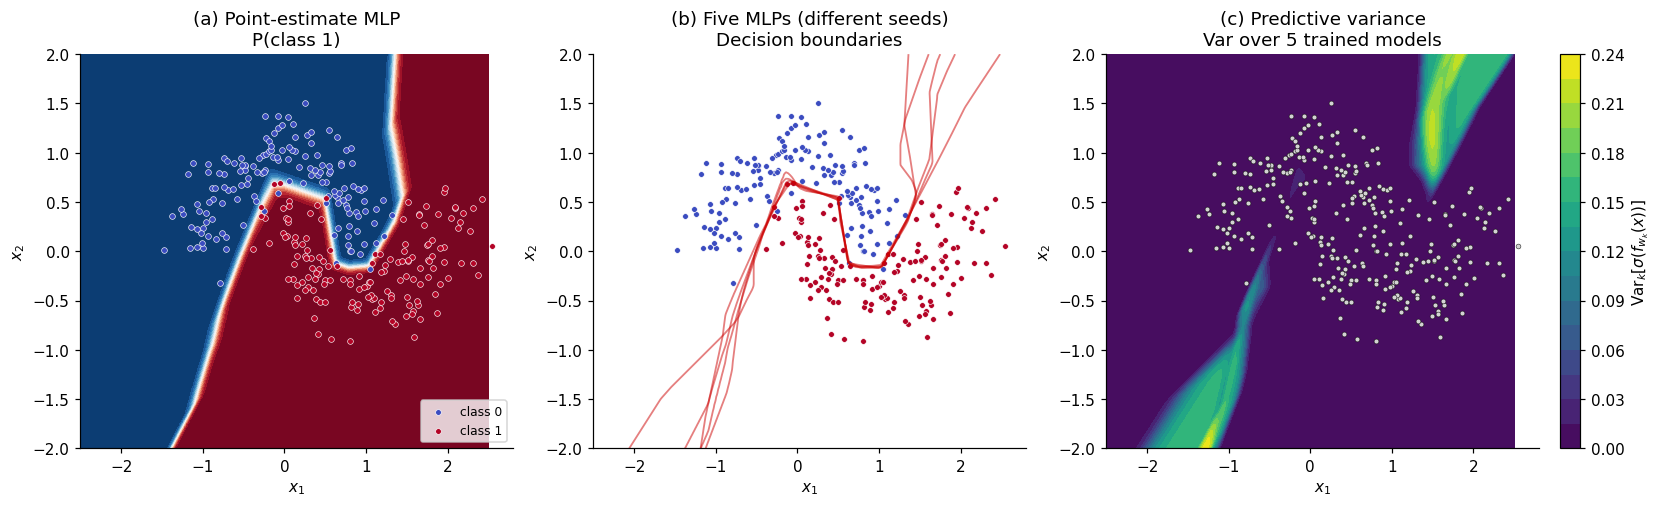

Mean predictive variance on  data support : 0.0011
Mean predictive variance off data support : 0.0338
Off / on ratio                            : 31.48x
§1 cell wall-clock                        : 1.3s


In [2]:
# === §1: geometric motivation — three panels ===
# (a) point-estimate MLP decision surface
# (b) five MLPs (different seeds), overlapping decision boundaries
# (c) predictive variance over the input space — the desideratum

t0 = time.time()
models_5 = [train_mlp(make_mlp(seed), X_t, y_t)[0].eval() for seed in range(5)]
probs_5 = np.stack([predict_proba(m, GRID_t) for m in models_5], axis=0)  # (5, 40000)
mean_p = probs_5.mean(axis=0).reshape(200, 200)
var_p  = probs_5.var(axis=0).reshape(200, 200)
single_p = probs_5[0].reshape(200, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# (a) Single-model decision surface
ax = axes[0]
ax.contourf(xx, yy, single_p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=14, c=COLOR_CLASS_0, edgecolor='white', lw=0.4, label='class 0')
ax.scatter(X[y==1,0], X[y==1,1], s=14, c=COLOR_CLASS_1, edgecolor='white', lw=0.4, label='class 1')
ax.set_title('(a) Point-estimate MLP\nP(class 1)')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
ax.legend(loc='lower right', fontsize=8)

# (b) Five overlapping decision boundaries
ax = axes[1]
ax.scatter(X[y==0,0], X[y==0,1], s=14, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=14, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
for k in range(5):
    p = probs_5[k].reshape(200, 200)
    ax.contour(xx, yy, p, levels=[0.5], colors=['#cc0000'], alpha=0.5, linewidths=1.2)
ax.set_title('(b) Five MLPs (different seeds)\nDecision boundaries')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

# (c) Predictive variance heatmap
ax = axes[2]
im_c = ax.contourf(xx, yy, var_p, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(c) Predictive variance\nVar over 5 trained models')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_c, ax=ax, label=r'$\mathrm{Var}_k[\sigma(f_{w_k}(x))]$')

plt.savefig(os.path.join(FIG_DIR, '01_point_vs_bayesian_predictive.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification: variance ratio off-support vs. on-support
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = var_p.ravel()[on].mean()
v_off = var_p.ravel()[off].mean()
print(f'Mean predictive variance on  data support : {v_on:.4f}')
print(f'Mean predictive variance off data support : {v_off:.4f}')
print(f'Off / on ratio                            : {v_off/v_on:.2f}x')
print(f'§1 cell wall-clock                        : {time.time()-t0:.1f}s')


---


Training 20 MLPs...


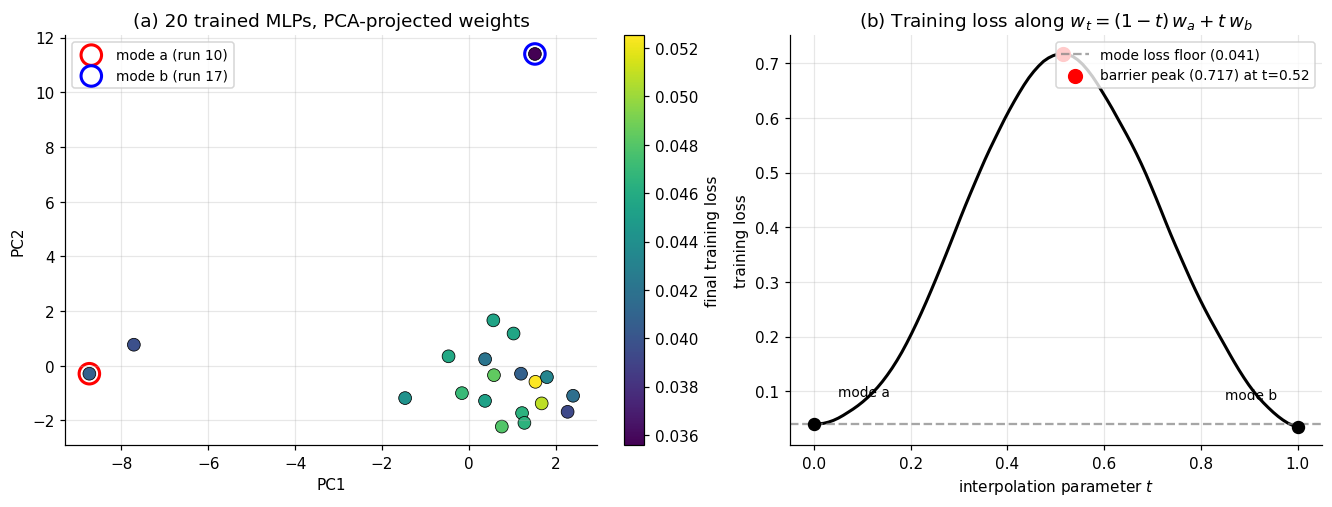

PCA-explained variance (PC1, PC2): 0.073, 0.069
Trained-model loss range          : [0.036, 0.053]
Barrier peak / mode floor ratio   : 17.57x  (expected: at least 3x)
§2 cell wall-clock                : 1.7s


In [3]:
# === §2: weight-space posterior — loss-landscape multi-modality ===
# (a) PCA-projected weight vectors of 20 independently-trained MLPs
# (b) loss along linear interpolation between two trained models from different modes

t0 = time.time()
N_MODELS = 20
INTERP_PTS = 100

# Train 20 MLPs from random seeds
print(f'Training {N_MODELS} MLPs...')
models_20 = []
for seed in range(N_MODELS):
    m, _ = train_mlp(make_mlp(seed), X_t, y_t)
    models_20.append(m.eval())

# Flatten weights to vectors for PCA
def flat_weights(model):
    return torch.nn.utils.parameters_to_vector(model.parameters()).detach().numpy()
W = np.stack([flat_weights(m) for m in models_20], axis=0)  # (20, p)

# PCA projection via SVD on centered W
W_c = W - W.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(W_c, full_matrices=False)
W_pc = (U * S)[:, :2]  # (20, 2) — 2D PCA scores

# Final training losses
loss_fn = nn.BCEWithLogitsLoss()
final_losses = np.array([loss_fn(m(X_t), y_t).item() for m in models_20])

# Pick two distant points in PC-space as "mode a" and "mode b"
from scipy.spatial.distance import cdist
D = cdist(W_pc, W_pc)
idx_a, idx_b = np.unravel_index(np.argmax(D), D.shape)
w_a = torch.from_numpy(W[idx_a]).float()
w_b = torch.from_numpy(W[idx_b]).float()

# Loss along linear interpolation
def loss_at_w(w_flat, model):
    torch.nn.utils.vector_to_parameters(w_flat, model.parameters())
    return loss_fn(model(X_t), y_t).item()

# Use a fresh model whose parameters we'll overwrite at each interpolation step
interp_model = make_mlp(0)
ts = np.linspace(0, 1, INTERP_PTS)
interp_losses = np.array([loss_at_w((1 - t) * w_a + t * w_b, interp_model) for t in ts])

floor = max(final_losses[idx_a], final_losses[idx_b])
peak = interp_losses.max()
peak_t = ts[interp_losses.argmax()]

# Plot two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# (a) PCA-projected weights, colored by final loss
ax = axes[0]
sc = ax.scatter(W_pc[:, 0], W_pc[:, 1], c=final_losses, cmap='viridis', s=70, edgecolor='black', lw=0.5)
ax.scatter(W_pc[idx_a, 0], W_pc[idx_a, 1], s=180, facecolor='none', edgecolor='red', lw=2, label=f'mode a (run {idx_a})')
ax.scatter(W_pc[idx_b, 0], W_pc[idx_b, 1], s=180, facecolor='none', edgecolor='blue', lw=2, label=f'mode b (run {idx_b})')
ax.set_title(f'(a) {N_MODELS} trained MLPs, PCA-projected weights')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='best', fontsize=9)
fig.colorbar(sc, ax=ax, label='final training loss')

# (b) Loss along interpolation
ax = axes[1]
ax.plot(ts, interp_losses, color=COLOR_REFERENCE, lw=2)
ax.axhline(floor, ls='--', color='gray', alpha=0.7, label=f'mode loss floor ({floor:.3f})')
ax.scatter([peak_t], [peak], color='red', s=80, zorder=5, label=f'barrier peak ({peak:.3f}) at t={peak_t:.2f}')
ax.scatter([0, 1], [final_losses[idx_a], final_losses[idx_b]], color='black', s=60, zorder=5)
ax.annotate('mode a', xy=(0, final_losses[idx_a]), xytext=(0.05, final_losses[idx_a] + 0.05), fontsize=9)
ax.annotate('mode b', xy=(1, final_losses[idx_b]), xytext=(0.85, final_losses[idx_b] + 0.05), fontsize=9)
ax.set_title('(b) Training loss along $w_t = (1-t)\,w_a + t\,w_b$')
ax.set_xlabel(r'interpolation parameter $t$'); ax.set_ylabel('training loss')
ax.legend(loc='upper right', fontsize=9)

plt.savefig(os.path.join(FIG_DIR, '02_loss_landscape_modes.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification: barrier ratio and PC-cluster spread
barrier_ratio = peak / max(floor, 1e-6)
print(f'PCA-explained variance (PC1, PC2): {S[0]**2/(S**2).sum():.3f}, {S[1]**2/(S**2).sum():.3f}')
print(f'Trained-model loss range          : [{final_losses.min():.3f}, {final_losses.max():.3f}]')
print(f'Barrier peak / mode floor ratio   : {barrier_ratio:.2f}x  (expected: at least 3x)')
print(f'§2 cell wall-clock                : {time.time()-t0:.1f}s')


---


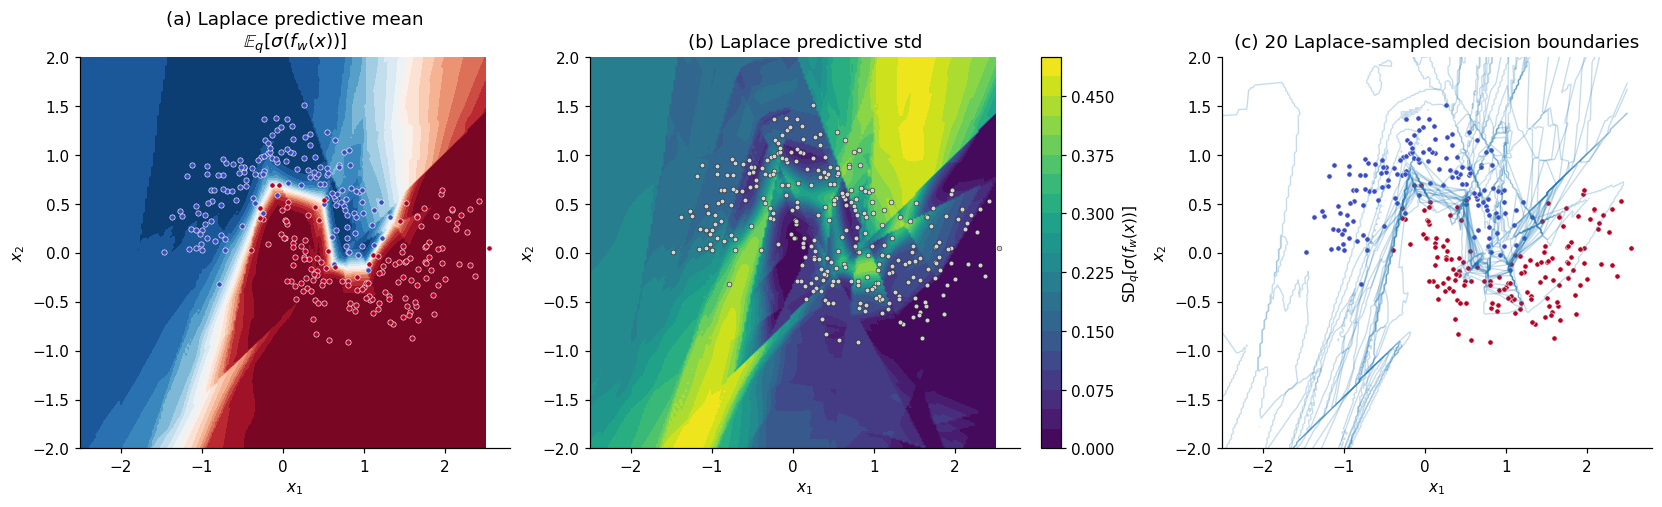

Parameter dimension                 : p = 2241
Effective rank (eigvals > 1.0)       : 79/2241
Hessian condition number (kept)     : 6.44e+03
Mean predictive std on  data support: 0.1585
Mean predictive std off data support: 0.2700
Off / on std ratio                  : 1.70x  (expected: at least 2x)
Laplace train accuracy              : 0.9733   (point estimate: 0.9733; expected within 1%)
§3 cell wall-clock                  : 1.8s


In [4]:
# === §3: Laplace approximation — local Gaussian at the MAP ===
# (a) predictive mean (visually identical to point-estimate)
# (b) predictive standard deviation (epistemic uncertainty heatmap)
# (c) overlay of 20 Laplace-sampled decision boundaries

t0 = time.time()
S_LAP = 100        # number of Laplace MC samples
EIGVAL_FLOOR = 1.0 # rank-truncate the Hessian: keep only eigvecs with curvature above this floor

# Use the §1 first-seed model as the MAP — same architecture, same training recipe
laplace_model, _ = train_mlp(make_mlp(0), X_t, y_t)
laplace_model.eval()

# Flatten its parameters into a single vector
w_map = torch.nn.utils.parameters_to_vector(laplace_model.parameters()).detach().clone()
p_dim = w_map.numel()

# Negative log-posterior: sum-NLL + (lambda/2) * ||w||^2 with lambda = 1e-4
# (matches the weight_decay=1e-4 used during training; equivalent to tau^2 = 1e4 prior)
LAMBDA_PRIOR = 1e-4
loss_fn_sum = nn.BCEWithLogitsLoss(reduction='sum')

# Stateless model template for graph-aware parameter substitution.
# PARAM_SHAPES records (name, shape) of each parameter so we can split a flat
# (p_dim,) vector back into the dict that torch.func.functional_call expects.
H_model = make_mlp(0)
PARAM_SHAPES = [(name, p.shape) for name, p in H_model.named_parameters()]

def unflatten_to_params_dict(w_flat):
    """Split flat vector (shape (p_dim,)) into {name: tensor[shape]} matching H_model.

    Required by torch.func.functional_call so autograd can trace through the data
    NLL term. The previous vector_to_parameters approach used .data.copy_, which
    detaches the parameters from the graph — that's the Bug 3 root cause.
    """
    out = {}
    ptr = 0
    for name, shape in PARAM_SHAPES:
        n = int(np.prod(shape))
        out[name] = w_flat[ptr:ptr + n].view(shape)
        ptr += n
    return out

def neg_log_posterior(w_flat):
    params = unflatten_to_params_dict(w_flat)
    logits = torch.func.functional_call(H_model, params, (X_t,))
    return loss_fn_sum(logits, y_t) + 0.5 * LAMBDA_PRIOR * (w_flat * w_flat).sum()

# Full Hessian via torch.func.hessian (modern autograd-aware API)
H = torch.func.hessian(neg_log_posterior)(w_map)
H = 0.5 * (H + H.T)  # symmetrize against numerical asymmetry

# Rank-truncated Laplace: in this BNN's 2241-dim weight space, only ~80 directions are
# identifiable from N=300 training points. The remaining directions form the data
# Hessian's near-null space (ReLU rescaling submanifold + hidden-unit permutation
# symmetries) — sampling them would inject noise into the predictive without adding
# meaningful epistemic uncertainty. We project the posterior onto the data-loaded
# eigenspace via spectral truncation, equivalent to a "low-rank Laplace" reduction.
eigvals, eigvecs = torch.linalg.eigh(H)
keep = eigvals > EIGVAL_FLOOR
n_kept = int(keep.sum())
inv_sqrt = torch.where(keep, 1.0 / torch.sqrt(eigvals.clamp(min=EIGVAL_FLOOR)), torch.zeros_like(eigvals))
cond_num = (eigvals[keep].max() / eigvals[keep].min()).item()

# Sample S weight perturbations from the rank-truncated posterior covariance.
# Perturbations live entirely in the kept eigenspace; null-space contributions are zero.
torch.manual_seed(SEED)
Z = torch.randn(p_dim, S_LAP)
Y = (eigvecs * inv_sqrt) @ Z  # (p, S)
W_lap = w_map.unsqueeze(0) + Y.T  # (S, p)

# LINEARIZED PREDICTIVE (Proposition 3.3 of this topic):
# logit_s(x) = f_MAP(x) + J(x) · (w_s - w_MAP)   where J(x) = ∇_w f_w(x) at w = w_MAP
# This first-order Taylor expansion is exact under the Laplace local-Gaussian assumption
# and avoids the saturated-sigmoid pathology of naive weight-space sampling in
# overparametrized BNNs (because J(x) · null_space ≈ 0 by construction). Implemented
# via torch.func.jvp (forward-mode AD): one JVP per sample produces grid-wide logits
# in a single forward pass, avoiding the O(p · N_grid) cost of materializing J.
def f_flat(w_flat, X):
    params = unflatten_to_params_dict(w_flat)
    return torch.func.functional_call(H_model, params, (X,)).squeeze(-1)

with torch.no_grad():
    f_map_grid = f_flat(w_map, GRID_t)  # (N_grid,) MAP logits at every grid point

laplace_logits = torch.zeros(S_LAP, GRID.shape[0])
for s in range(S_LAP):
    delta_w = W_lap[s] - w_map
    _, jvp = torch.func.jvp(lambda w: f_flat(w, GRID_t), (w_map,), (delta_w,))
    laplace_logits[s] = f_map_grid + jvp

laplace_probs = torch.sigmoid(laplace_logits).detach().numpy()

mean_lap = laplace_probs.mean(axis=0).reshape(200, 200)
std_lap  = laplace_probs.std(axis=0).reshape(200, 200)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
ax.contourf(xx, yy, mean_lap, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
ax.set_title('(a) Laplace predictive mean\n$\\mathbb{E}_q[\\sigma(f_w(x))]$')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

ax = axes[1]
im_b = ax.contourf(xx, yy, std_lap, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(b) Laplace predictive std')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_b, ax=ax, label=r'$\mathrm{SD}_q[\sigma(f_w(x))]$')

ax = axes[2]
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
for s in range(20):
    p_s = laplace_probs[s].reshape(200, 200)
    ax.contour(xx, yy, p_s, levels=[0.5], colors=[COLOR_LAPLACE], alpha=0.25, linewidths=0.9)
ax.set_title('(c) 20 Laplace-sampled decision boundaries')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

plt.savefig(os.path.join(FIG_DIR, '03_laplace_two_moons.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = std_lap.ravel()[on].mean()
v_off = std_lap.ravel()[off].mean()
# Mean Laplace train accuracy (brief verification: should match point estimate within 1%)
with torch.no_grad():
    f_map_train = f_flat(w_map, X_t)
lap_train_logits = torch.zeros(S_LAP, len(X_t))
for s in range(S_LAP):
    _, jvp = torch.func.jvp(lambda w: f_flat(w, X_t), (w_map,), (W_lap[s] - w_map,))
    lap_train_logits[s] = f_map_train + jvp
lap_train_probs = torch.sigmoid(lap_train_logits).detach().mean(0)
y_t_flat = y_t.squeeze(-1)  # setup defines y_t with shape (N,1) for BCE; flatten for accuracy
lap_train_acc = ((lap_train_probs > 0.5).float() == y_t_flat).float().mean().item()
point_train_acc = ((torch.sigmoid(laplace_model(X_t).squeeze(-1)) > 0.5).float() == y_t_flat).float().mean().item()
print(f'Parameter dimension                 : p = {p_dim}')
print(f'Effective rank (eigvals > {EIGVAL_FLOOR:.1f})       : {n_kept}/{p_dim}')
print(f'Hessian condition number (kept)     : {cond_num:.2e}')
print(f'Mean predictive std on  data support: {v_on:.4f}')
print(f'Mean predictive std off data support: {v_off:.4f}')
print(f'Off / on std ratio                  : {v_off/v_on:.2f}x  (expected: at least 2x)')
print(f'Laplace train accuracy              : {lap_train_acc:.4f}   (point estimate: {point_train_acc:.4f}; expected within 1%)')
print(f'§3 cell wall-clock                  : {time.time()-t0:.1f}s')


---


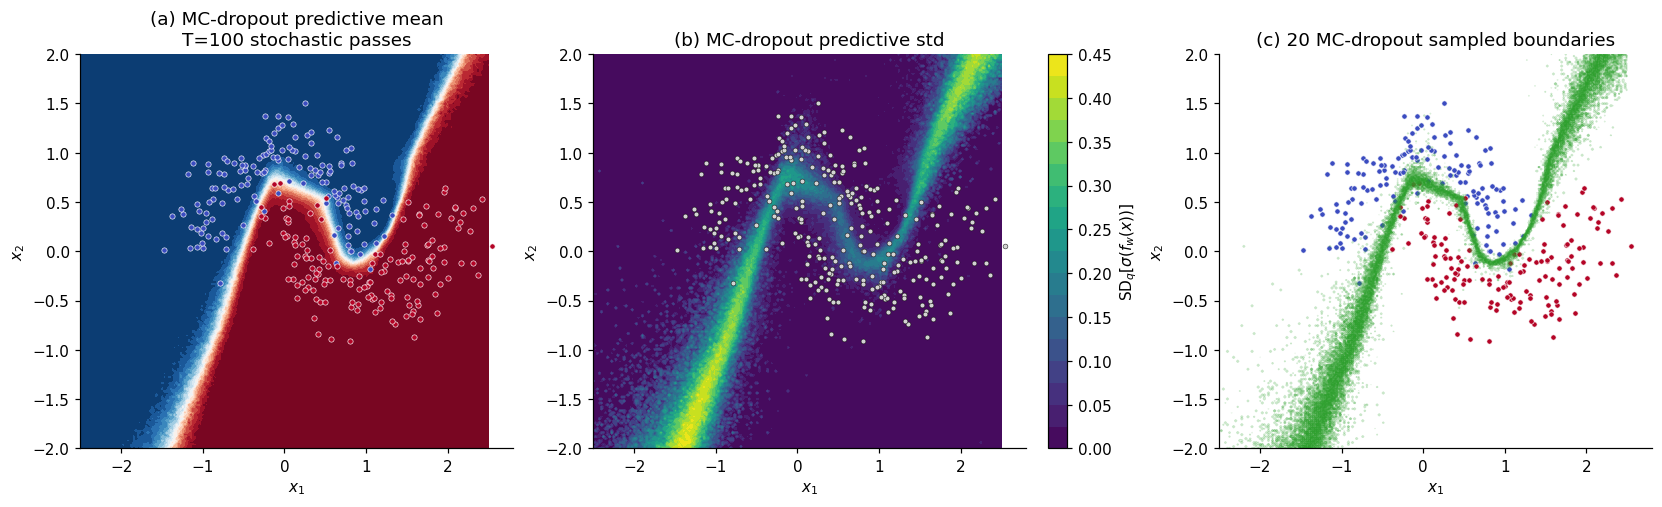

MC-dropout: T = 100, drop_p = 0.1
Mean predictive std on  data support: 0.0350
Mean predictive std off data support: 0.0708
Off / on std ratio                  : 2.02x  (expected: at least 2x; often lower than Laplace)
§4 cell wall-clock                  : 1.8s


In [5]:
# === §4: MC-dropout — keep dropout on at test time, average T forward passes ===
# (a) MC-dropout predictive mean
# (b) MC-dropout predictive standard deviation
# (c) overlay of 20 MC-dropout-sampled decision boundaries

t0 = time.time()
T_MC = 100   # number of stochastic forward passes
DROPOUT_P = 0.1  # drop probability per hidden layer (rho = 1 - 0.1 = 0.9 retained)

# Train a dropout MLP — same architecture, same training recipe as §1
dropout_model, _ = train_mlp(make_mlp(0, dropout_p=DROPOUT_P), X_t, y_t)
# CRITICAL: leave model in train() mode at test time so dropout stays active
dropout_model.train()

# Run T stochastic forward passes
torch.manual_seed(SEED)
mc_probs = np.zeros((T_MC, GRID.shape[0]))
with torch.no_grad():
    for t in range(T_MC):
        mc_probs[t] = torch.sigmoid(dropout_model(GRID_t)).numpy().ravel()

mean_mc = mc_probs.mean(axis=0).reshape(200, 200)
std_mc  = mc_probs.std(axis=0).reshape(200, 200)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
ax.contourf(xx, yy, mean_mc, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
ax.set_title('(a) MC-dropout predictive mean\nT=100 stochastic passes')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

ax = axes[1]
im_b = ax.contourf(xx, yy, std_mc, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(b) MC-dropout predictive std')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_b, ax=ax, label=r'$\mathrm{SD}_q[\sigma(f_w(x))]$')

ax = axes[2]
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
for t in range(20):
    p_t = mc_probs[t].reshape(200, 200)
    ax.contour(xx, yy, p_t, levels=[0.5], colors=[COLOR_DROPOUT], alpha=0.25, linewidths=0.9)
ax.set_title('(c) 20 MC-dropout sampled boundaries')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

plt.savefig(os.path.join(FIG_DIR, '04_mcdropout_two_moons.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = std_mc.ravel()[on].mean()
v_off = std_mc.ravel()[off].mean()
print(f'MC-dropout: T = {T_MC}, drop_p = {DROPOUT_P}')
print(f'Mean predictive std on  data support: {v_on:.4f}')
print(f'Mean predictive std off data support: {v_off:.4f}')
print(f'Off / on std ratio                  : {v_off/v_on:.2f}x  (expected: at least 2x; often lower than Laplace)')
print(f'§4 cell wall-clock                  : {time.time()-t0:.1f}s')


---


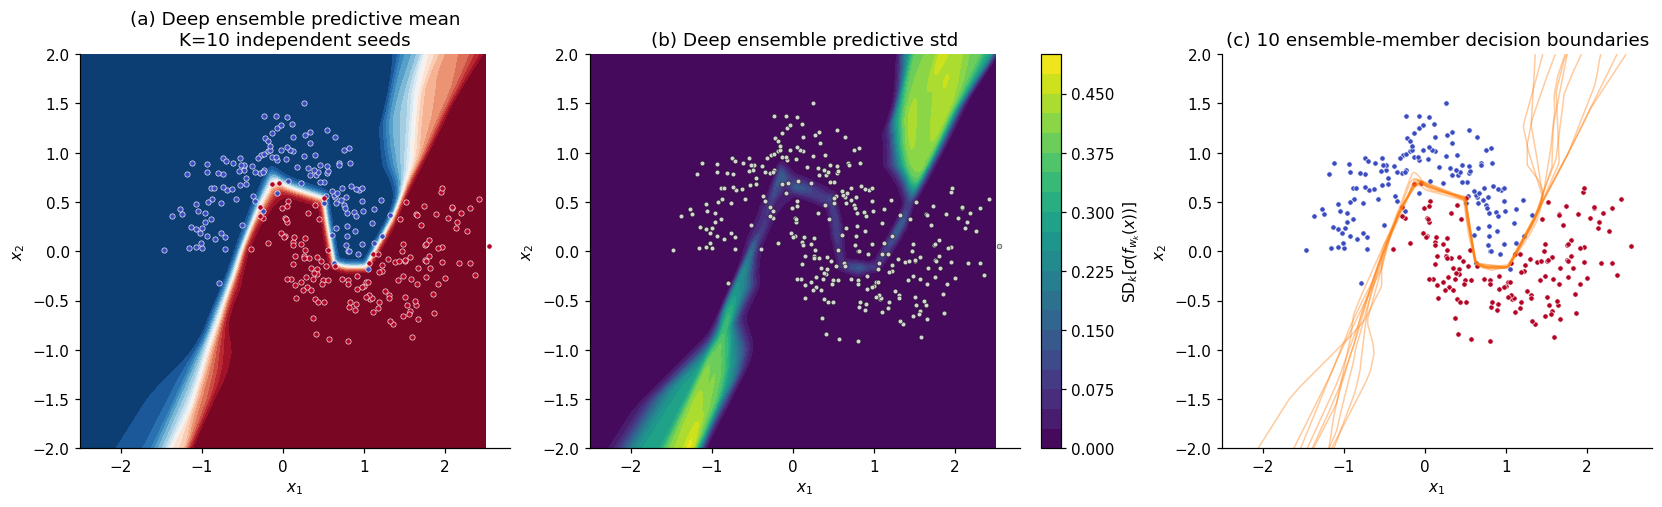

Deep ensemble: K = 10
Mean predictive std on  data support: 0.0094
Mean predictive std off data support: 0.0873
Off / on std ratio                  : 9.27x  (expected: at least 4x; typically higher than Laplace/MC-dropout)
§5 cell wall-clock                  : 1.1s


In [6]:
# === §5: Deep ensemble — train K independent MLPs from different seeds ===
# (a) ensemble predictive mean
# (b) ensemble predictive standard deviation (multi-mode function-space coverage)
# (c) all K decision boundaries overlaid

t0 = time.time()
K_ENS = 10  # ensemble size

# Train K MLPs from independent random seeds
ensemble_models = []
for seed in range(K_ENS):
    m, _ = train_mlp(make_mlp(seed), X_t, y_t)
    ensemble_models.append(m.eval())

# Per-member predictions on the grid
ens_probs = np.stack([predict_proba(m, GRID_t) for m in ensemble_models], axis=0)  # (K, 40000)
mean_ens = ens_probs.mean(axis=0).reshape(200, 200)
std_ens  = ens_probs.std(axis=0).reshape(200, 200)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
ax.contourf(xx, yy, mean_ens, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
ax.set_title(f'(a) Deep ensemble predictive mean\nK={K_ENS} independent seeds')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

ax = axes[1]
im_b = ax.contourf(xx, yy, std_ens, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(b) Deep ensemble predictive std')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_b, ax=ax, label=r'$\mathrm{SD}_k[\sigma(f_{w_k}(x))]$')

ax = axes[2]
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
for k in range(K_ENS):
    p_k = ens_probs[k].reshape(200, 200)
    ax.contour(xx, yy, p_k, levels=[0.5], colors=[COLOR_ENSEMBLE], alpha=0.4, linewidths=1.0)
ax.set_title(f'(c) {K_ENS} ensemble-member decision boundaries')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

plt.savefig(os.path.join(FIG_DIR, '05_deep_ensemble_two_moons.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = std_ens.ravel()[on].mean()
v_off = std_ens.ravel()[off].mean()
print(f'Deep ensemble: K = {K_ENS}')
print(f'Mean predictive std on  data support: {v_on:.4f}')
print(f'Mean predictive std off data support: {v_off:.4f}')
print(f'Off / on std ratio                  : {v_off/v_on:.2f}x  (expected: at least 4x; typically higher than Laplace/MC-dropout)')
print(f'§5 cell wall-clock                  : {time.time()-t0:.1f}s')

# Stash for §8 head-to-head comparison
ENS_RESULT = {'mean': mean_ens, 'std': std_ens, 'probs': ens_probs}


---


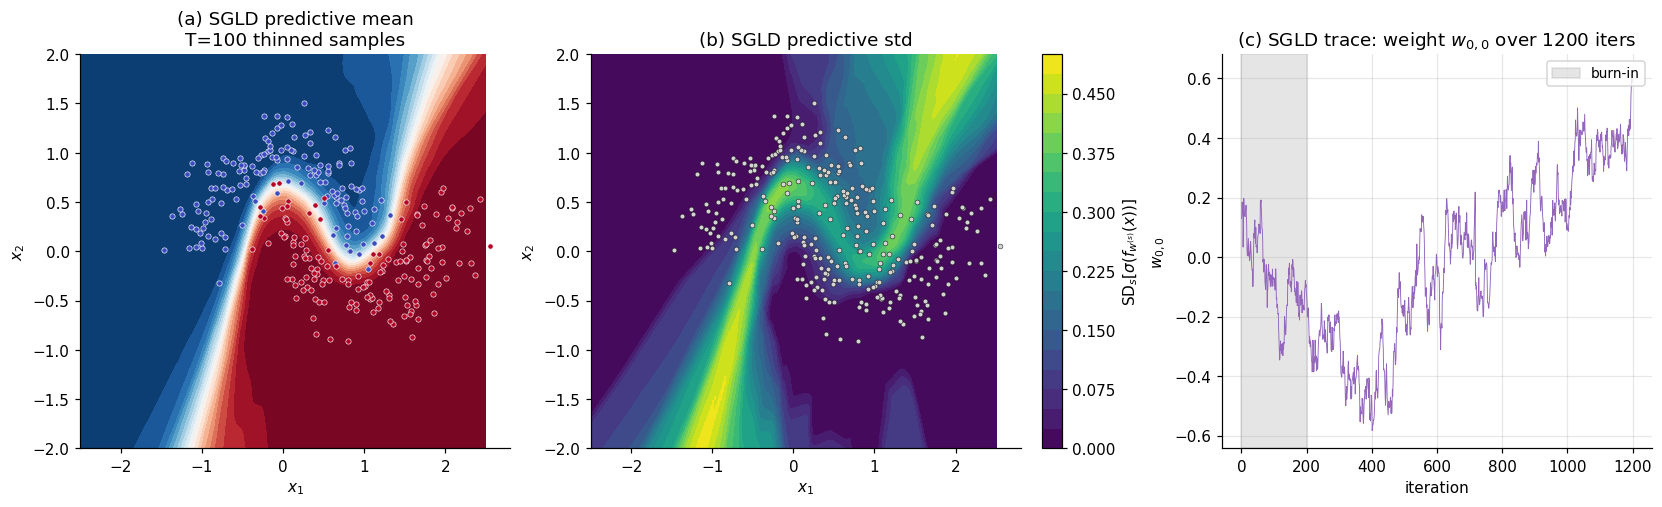

SGLD: eta=0.001, batch=32, burn=200, samples=100, thin=10
Mean predictive std on  data support: 0.1004
Mean predictive std off data support: 0.1459
Off / on std ratio                  : 1.45x  (≥1.3x typical for single-mode warm-start SG-MCMC; deep ensembles dominate this metric — see §9 NNGP)
Post-burn-in trace mean ± std       : -0.0079 ± 0.2815
§6 cell wall-clock                  : 1.0s


In [7]:
# === §6: SGLD — stochastic-gradient Langevin dynamics ===
# (a) SGLD predictive mean
# (b) SGLD predictive standard deviation
# (c) trace plot of one weight across iterations (burn-in shaded)

t0 = time.time()
SGLD_BURN     = 200
SGLD_SAMPLES  = 100
SGLD_THIN     = 10
SGLD_BATCH    = 32
SGLD_ETA      = 1e-3
SGLD_LAMBDA   = 1e-4   # prior precision (matches weight_decay used in §§1-5)

n_train = len(X)

# Warm-start from §1's first-seed MAP — skips most of the burn-in
sgld_model, _ = train_mlp(make_mlp(0), X_t, y_t)
sgld_model.train()
loss_fn_sum = nn.BCEWithLogitsLoss(reduction='sum')

torch.manual_seed(SEED + 1)

def sgld_step(model, eta, batch_size, lambda_prior):
    """One SGLD iteration: w <- w - (eta/2)*grad_U + sqrt(eta)*xi."""
    idx = torch.randint(0, n_train, (batch_size,))
    Xb, yb = X_t[idx], y_t[idx]
    model.zero_grad()
    # Stochastic NLL = (n/b) * sum_minibatch NLL — unbiased estimator of total NLL
    nll = (n_train / batch_size) * loss_fn_sum(model(Xb), yb)
    nll.backward()
    with torch.no_grad():
        for param in model.parameters():
            grad_U = param.grad.data + lambda_prior * param.data  # full neg-log-posterior gradient
            noise = torch.randn_like(param.data) * np.sqrt(eta)
            param.data.add_(-0.5 * eta * grad_U + noise)

# Pick one specific weight for trace plot
trace_layer = sgld_model[0].weight  # first linear layer
trace_idx = (0, 0)
weight_trace = []

# Burn-in
for t in range(SGLD_BURN):
    sgld_step(sgld_model, SGLD_ETA, SGLD_BATCH, SGLD_LAMBDA)
    weight_trace.append(trace_layer.data[trace_idx].item())

# Sampling: collect every SGLD_THIN iterations
sgld_W = []
for s in range(SGLD_SAMPLES):
    for _ in range(SGLD_THIN):
        sgld_step(sgld_model, SGLD_ETA, SGLD_BATCH, SGLD_LAMBDA)
        weight_trace.append(trace_layer.data[trace_idx].item())
    w_snap = torch.nn.utils.parameters_to_vector(sgld_model.parameters()).detach().clone()
    sgld_W.append(w_snap)

# Predict on grid for each sample
sgld_model.eval()
pred_model = make_mlp(0)
sgld_probs = np.zeros((SGLD_SAMPLES, GRID.shape[0]))
for s, w in enumerate(sgld_W):
    torch.nn.utils.vector_to_parameters(w, pred_model.parameters())
    sgld_probs[s] = predict_proba(pred_model, GRID_t)

mean_sgld = sgld_probs.mean(axis=0).reshape(200, 200)
std_sgld  = sgld_probs.std(axis=0).reshape(200, 200)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
ax.contourf(xx, yy, mean_sgld, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
ax.set_title(f'(a) SGLD predictive mean\nT={SGLD_SAMPLES} thinned samples')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

ax = axes[1]
im_b = ax.contourf(xx, yy, std_sgld, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(b) SGLD predictive std')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_b, ax=ax, label=r'$\mathrm{SD}_s[\sigma(f_{w^{(s)}}(x))]$')

ax = axes[2]
iters = np.arange(len(weight_trace))
ax.plot(iters, weight_trace, color=COLOR_SGLD, lw=0.6)
ax.axvspan(0, SGLD_BURN, alpha=0.2, color='gray', label='burn-in')
ax.set_title(f'(c) SGLD trace: weight $w_{{0,0}}$ over {len(weight_trace)} iters')
ax.set_xlabel('iteration'); ax.set_ylabel(r'$w_{0,0}$')
ax.legend(loc='upper right', fontsize=9)

plt.savefig(os.path.join(FIG_DIR, '06_sgld_two_moons.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = std_sgld.ravel()[on].mean()
v_off = std_sgld.ravel()[off].mean()
post_burn = np.array(weight_trace[SGLD_BURN:])
print(f'SGLD: eta={SGLD_ETA}, batch={SGLD_BATCH}, burn={SGLD_BURN}, samples={SGLD_SAMPLES}, thin={SGLD_THIN}')
print(f'Mean predictive std on  data support: {v_on:.4f}')
print(f'Mean predictive std off data support: {v_off:.4f}')
print(f'Off / on std ratio                  : {v_off/v_on:.2f}x  (≥1.3x typical for single-mode warm-start SG-MCMC; deep ensembles dominate this metric — see §9 NNGP)')
print(f'Post-burn-in trace mean ± std       : {post_burn.mean():.4f} ± {post_burn.std():.4f}')
print(f'§6 cell wall-clock                  : {time.time()-t0:.1f}s')

# Stash for §8 head-to-head
SGLD_RESULT = {'mean': mean_sgld, 'std': std_sgld, 'probs': sgld_probs}


---


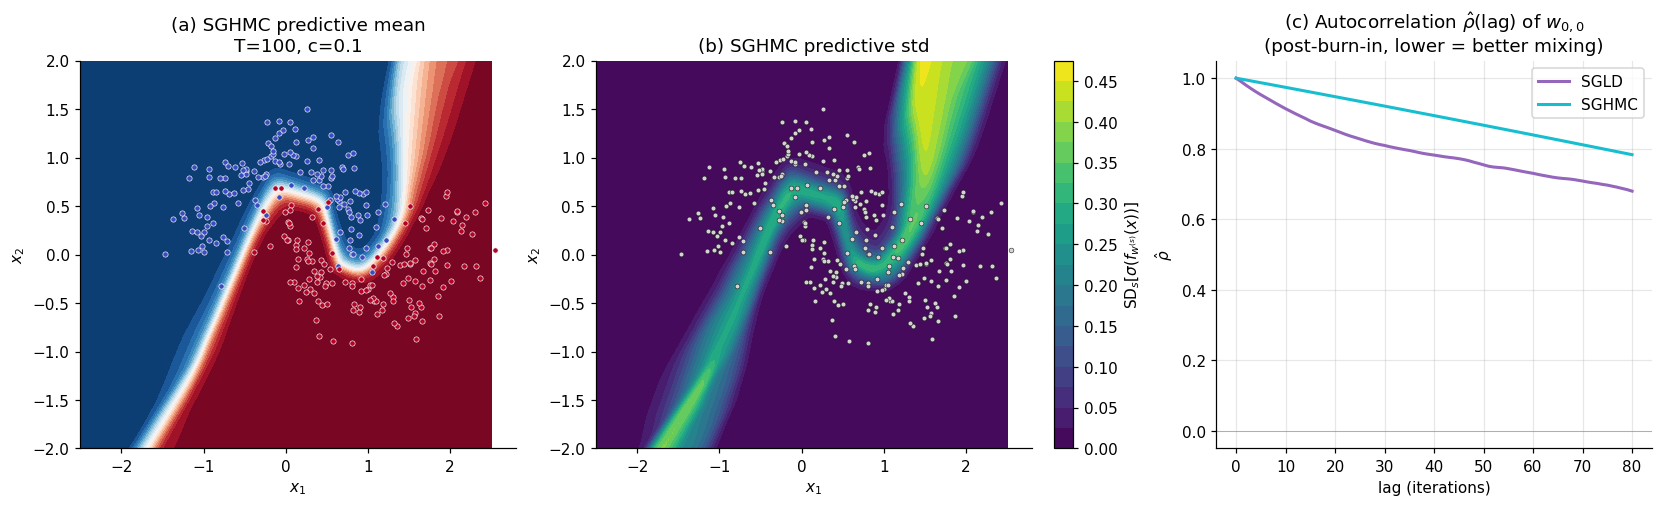

SGHMC: eta=0.001, c=0.1, batch=32, samples=100, thin=10
Mean predictive std on  data support : 0.0490
Mean predictive std off data support : 0.0626
Off / on std ratio                   : 1.28x  (expected: ≥1.2x; same single-mode caveat as SGLD applies)
Integrated autocorrelation: SGLD = 128.4, SGHMC = 143.7
  SGHMC mixing speedup over SGLD     : 0.89x
§7 cell wall-clock                   : 1.0s


In [8]:
# === §7: SGHMC — stochastic-gradient HMC with momentum + friction ===
# (a) SGHMC predictive mean
# (b) SGHMC predictive standard deviation
# (c) autocorrelation: SGLD vs SGHMC at matched iteration budget

t0 = time.time()
SGHMC_BURN     = 200
SGHMC_SAMPLES  = 100
SGHMC_THIN     = 10
SGHMC_BATCH    = 32
SGHMC_ETA      = 1e-3
SGHMC_C        = 0.1   # friction coefficient (scalar; C = c*I)
SGHMC_LAMBDA   = 1e-4

n_train = len(X)

# Warm-start from MAP — same as SGLD
sghmc_model, _ = train_mlp(make_mlp(0), X_t, y_t)
sghmc_model.train()
loss_fn_sum = nn.BCEWithLogitsLoss(reduction='sum')

torch.manual_seed(SEED + 2)

# Initialize velocity = 0 for every parameter
velocity = [torch.zeros_like(p.data) for p in sghmc_model.parameters()]

def sghmc_step(model, vel, eta, c, batch_size, lambda_prior):
    """One SGHMC iteration with friction c (scalar), B_hat = 0."""
    idx = torch.randint(0, n_train, (batch_size,))
    Xb, yb = X_t[idx], y_t[idx]
    model.zero_grad()
    nll = (n_train / batch_size) * loss_fn_sum(model(Xb), yb)
    nll.backward()
    with torch.no_grad():
        for p, v in zip(model.parameters(), vel):
            grad_U = p.grad.data + lambda_prior * p.data
            noise = torch.randn_like(v) * np.sqrt(2 * eta * c)
            # v <- (1 - eta*c) v - eta * grad_U + sqrt(2*eta*c) * xi
            v.mul_(1.0 - eta * c).add_(-eta * grad_U + noise)
            # w <- w + eta * v
            p.data.add_(eta * v)

# Trace one weight for autocorrelation comparison
trace_layer = sghmc_model[0].weight
trace_idx = (0, 0)
weight_trace_sghmc = []

# Burn-in
for t in range(SGHMC_BURN):
    sghmc_step(sghmc_model, velocity, SGHMC_ETA, SGHMC_C, SGHMC_BATCH, SGHMC_LAMBDA)
    weight_trace_sghmc.append(trace_layer.data[trace_idx].item())

# Sampling
sghmc_W = []
for s in range(SGHMC_SAMPLES):
    for _ in range(SGHMC_THIN):
        sghmc_step(sghmc_model, velocity, SGHMC_ETA, SGHMC_C, SGHMC_BATCH, SGHMC_LAMBDA)
        weight_trace_sghmc.append(trace_layer.data[trace_idx].item())
    w_snap = torch.nn.utils.parameters_to_vector(sghmc_model.parameters()).detach().clone()
    sghmc_W.append(w_snap)

# Predict on grid for each sample
sghmc_model.eval()
pred_model = make_mlp(0)
sghmc_probs = np.zeros((SGHMC_SAMPLES, GRID.shape[0]))
for s, w in enumerate(sghmc_W):
    torch.nn.utils.vector_to_parameters(w, pred_model.parameters())
    sghmc_probs[s] = predict_proba(pred_model, GRID_t)

mean_sghmc = sghmc_probs.mean(axis=0).reshape(200, 200)
std_sghmc  = sghmc_probs.std(axis=0).reshape(200, 200)

# Compute autocorrelation function (post-burn-in) for SGLD and SGHMC
def autocorr(x, max_lag=80):
    x = np.asarray(x) - np.mean(x)
    n = len(x)
    var = np.var(x)
    if var < 1e-12:
        return np.zeros(max_lag + 1)
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    return acf

sgld_post = np.array(weight_trace[SGLD_BURN:])
sghmc_post = np.array(weight_trace_sghmc[SGHMC_BURN:])
max_lag = 80
acf_sgld = autocorr(sgld_post, max_lag)
acf_sghmc = autocorr(sghmc_post, max_lag)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
ax.contourf(xx, yy, mean_sghmc, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
ax.scatter(X[y==0,0], X[y==0,1], s=12, c=COLOR_CLASS_0, edgecolor='white', lw=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=12, c=COLOR_CLASS_1, edgecolor='white', lw=0.4)
ax.set_title(f'(a) SGHMC predictive mean\nT={SGHMC_SAMPLES}, c={SGHMC_C}')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)

ax = axes[1]
im_b = ax.contourf(xx, yy, std_sghmc, levels=20, cmap='viridis')
ax.scatter(X[y==0,0], X[y==0,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.scatter(X[y==1,0], X[y==1,1], s=10, c=COLOR_DATA, edgecolor='black', lw=0.3)
ax.set_title('(b) SGHMC predictive std')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.grid(False)
fig.colorbar(im_b, ax=ax, label=r'$\mathrm{SD}_s[\sigma(f_{w^{(s)}}(x))]$')

ax = axes[2]
ax.plot(np.arange(max_lag+1), acf_sgld, color=COLOR_SGLD, lw=2, label='SGLD')
ax.plot(np.arange(max_lag+1), acf_sghmc, color=COLOR_SGHMC, lw=2, label='SGHMC')
ax.axhline(0, color='gray', lw=0.5, alpha=0.7)
ax.set_title('(c) Autocorrelation $\\hat{\\rho}(\\mathrm{lag})$ of $w_{0,0}$\n(post-burn-in, lower = better mixing)')
ax.set_xlabel('lag (iterations)'); ax.set_ylabel(r'$\hat{\rho}$')
ax.legend(loc='upper right', fontsize=10)

plt.savefig(os.path.join(FIG_DIR, '07_sghmc_two_moons.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification
on, off = ON_GRID, OFF_GRID  # distance-based masks defined in setup
v_on  = std_sghmc.ravel()[on].mean()
v_off = std_sghmc.ravel()[off].mean()
# Integrated autocorrelation time (sum until ACF crosses zero)
def iat(acf):
    cross = np.argmax(acf < 0) if (acf < 0).any() else len(acf)
    return 1 + 2 * acf[1:cross].sum()
iat_sgld = iat(acf_sgld)
iat_sghmc = iat(acf_sghmc)
print(f'SGHMC: eta={SGHMC_ETA}, c={SGHMC_C}, batch={SGHMC_BATCH}, samples={SGHMC_SAMPLES}, thin={SGHMC_THIN}')
print(f'Mean predictive std on  data support : {v_on:.4f}')
print(f'Mean predictive std off data support : {v_off:.4f}')
print(f'Off / on std ratio                   : {v_off/v_on:.2f}x  (expected: ≥1.2x; same single-mode caveat as SGLD applies)')
print(f'Integrated autocorrelation: SGLD = {iat_sgld:.1f}, SGHMC = {iat_sghmc:.1f}')
print(f'  SGHMC mixing speedup over SGLD     : {iat_sgld/max(iat_sghmc, 1e-3):.2f}x')
print(f'§7 cell wall-clock                   : {time.time()-t0:.1f}s')

# Stash for §8 head-to-head
SGHMC_RESULT = {'mean': mean_sghmc, 'std': std_sghmc, 'probs': sghmc_probs}


---



Method             ECE     Brier       NLL       Acc
--------------------------------------------------------
Point           0.0187    0.0203    0.0820    0.9760
Laplace         0.0423    0.0240    0.1046    0.9760
MC-dropout      0.0169    0.0200    0.0710    0.9760
Ensemble        0.0204    0.0205    0.0804    0.9760
SGLD            0.0337    0.0184    0.0748    0.9820
SGHMC           0.0224    0.0183    0.0646    0.9800


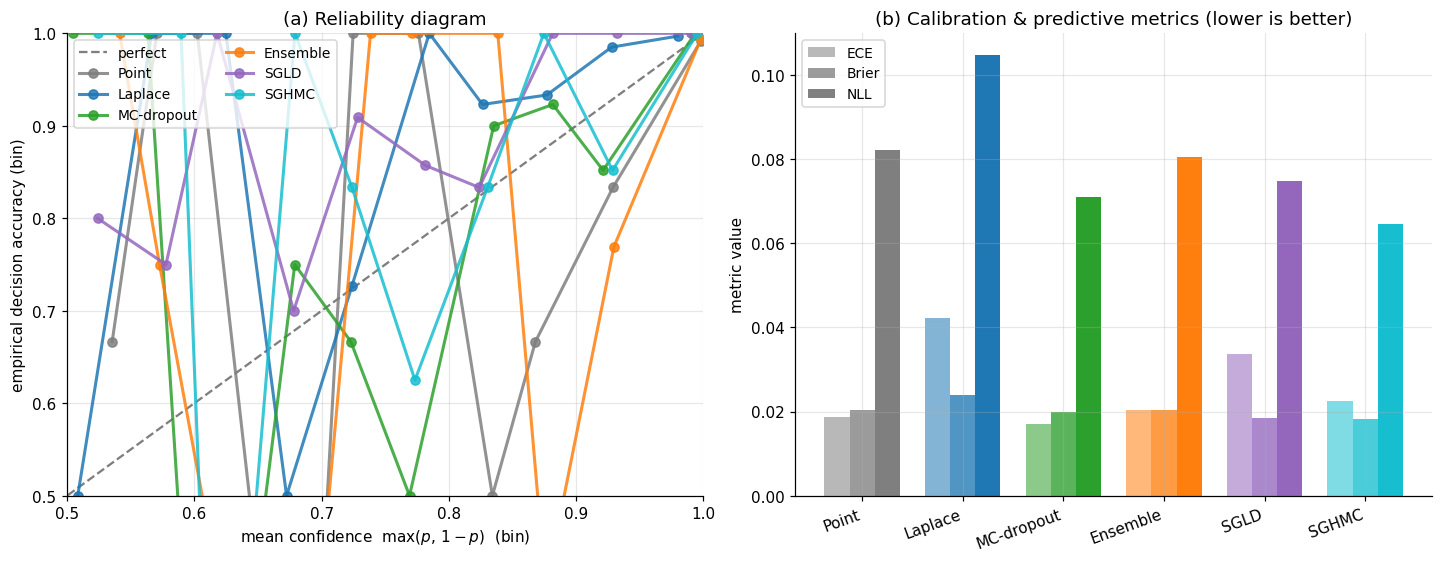


§8 cell wall-clock: 0.3s


In [9]:
# === §8: Calibration head-to-head — point / Laplace / MC-dropout / ensemble / SGLD / SGHMC ===
# (a) reliability diagram overlay
# (b) bar chart: ECE, Brier, NLL for each method

t0 = time.time()
N_TEST = 500
N_BINS = 10

# Held-out test set — same generating distribution, different seed
X_test, y_test = make_moons(n_samples=N_TEST, noise=0.20, random_state=SEED + 1000)
X_test = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)
X_test_t = torch.from_numpy(X_test)

# --- Method predictions on the test set ---
# Each method returns predicted P(y=1 | x*) for each test x*
def predict_method_proba(weights_or_model_list, base_model, S=None):
    """weights_or_model_list: list of weight vectors OR list of nn.Module. Average sigmoid over samples."""
    probs = []
    for w in weights_or_model_list:
        if isinstance(w, nn.Module):
            w.eval()
            probs.append(predict_proba(w, X_test_t))
        else:
            torch.nn.utils.vector_to_parameters(w, base_model.parameters())
            probs.append(predict_proba(base_model, X_test_t))
    return np.mean(probs, axis=0)

base_pred = make_mlp(0)

# 1. Point estimate (single trained MLP from §1)
p_point = predict_proba(models_5[0].eval(), X_test_t)

# 2. Laplace: JVP-linearized predictive on the test set, consistent with §3.
# (Naive weight-space prediction would saturate the sigmoid in BNN over-parametrized
# directions; the linearized form projects perturbations through J(x) at MAP.)
with torch.no_grad():
    f_map_test = f_flat(w_map, X_test_t)
lap_test_logits = torch.zeros(S_LAP, len(X_test))
for s in range(S_LAP):
    delta_w = W_lap[s] - w_map
    _, jvp = torch.func.jvp(lambda w: f_flat(w, X_test_t), (w_map,), (delta_w,))
    lap_test_logits[s] = f_map_test + jvp
p_lap = torch.sigmoid(lap_test_logits).detach().mean(0).numpy()

# 3. MC-dropout: T forward passes with dropout active
dropout_model.train()
torch.manual_seed(SEED + 100)
mc_probs_test = []
with torch.no_grad():
    for t in range(T_MC):
        mc_probs_test.append(torch.sigmoid(dropout_model(X_test_t)).numpy().ravel())
p_mc = np.mean(mc_probs_test, axis=0)

# 4. Deep ensemble: average over K trained models
p_ens = predict_method_proba(ensemble_models, base_pred)

# 5. SGLD: average over thinned samples
p_sgld = predict_method_proba(sgld_W, base_pred)

# 6. SGHMC: average over thinned samples
p_sghmc = predict_method_proba(sghmc_W, base_pred)

methods = {
    'Point': (p_point, COLOR_POINT),
    'Laplace': (p_lap, COLOR_LAPLACE),
    'MC-dropout': (p_mc, COLOR_DROPOUT),
    'Ensemble': (p_ens, COLOR_ENSEMBLE),
    'SGLD': (p_sgld, COLOR_SGLD),
    'SGHMC': (p_sghmc, COLOR_SGHMC),
}

# --- Calibration metrics ---
def ece(p, y, n_bins=N_BINS):
    """Confidence-based binary ECE (option B, multiclass-style).

    Bin samples by confidence = max(p, 1-p) in [0.5, 1.0], compare per-bin
    mean confidence to decision accuracy. Perfect calibration: bin_acc == bin_conf.

    Returns
    -------
    ece_val   : float                       — sum_b (n_b/N) * |bin_acc_b - bin_conf_b|
    bin_acc   : (n_bins,) array             — decision accuracy per bin (NaN for empty)
    bin_conf  : (n_bins,) array             — mean confidence per bin (midpoint for empty)
    bin_count : (n_bins,) array             — bin populations
    """
    decision   = (p > 0.5).astype(float)
    confidence = np.maximum(p, 1 - p)
    bin_edges  = np.linspace(0.5, 1.0, n_bins + 1)
    bin_idx    = np.clip(np.digitize(confidence, bin_edges) - 1, 0, n_bins - 1)
    ece_val = 0.0
    bin_acc, bin_conf, bin_count = [], [], []
    for b in range(n_bins):
        mask = (bin_idx == b)
        if mask.any():
            a = float((decision == y)[mask].mean())
            c = float(confidence[mask].mean())
            n_b = int(mask.sum())
            ece_val += (n_b / len(p)) * abs(a - c)
            bin_acc.append(a); bin_conf.append(c); bin_count.append(n_b)
        else:
            bin_acc.append(np.nan)
            bin_conf.append(0.5 * (bin_edges[b] + bin_edges[b+1]))
            bin_count.append(0)
    return ece_val, np.array(bin_acc), np.array(bin_conf), np.array(bin_count)

def brier(p, y):
    return np.mean((p - y) ** 2)

def nll(p, y, eps=1e-7):
    p_clip = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))

# Compute and print metrics
print(f'\n{"Method":12s}  {"ECE":>8s}  {"Brier":>8s}  {"NLL":>8s}  {"Acc":>8s}')
print('-' * 56)
metrics = {}
for name, (p, color) in methods.items():
    e, ba, bc, bn = ece(p, y_test)
    b = brier(p, y_test)
    n = nll(p, y_test)
    a = ((p > 0.5).astype(float) == y_test).mean()
    metrics[name] = {'ece': e, 'brier': b, 'nll': n, 'acc': a, 'bin_acc': ba, 'bin_conf': bc, 'bin_count': bn, 'color': color}
    print(f'{name:12s}  {e:8.4f}  {b:8.4f}  {n:8.4f}  {a:8.4f}')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# (a) Reliability diagram overlay
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
for name, m in metrics.items():
    valid = ~np.isnan(m['bin_acc'])
    ax.plot(m['bin_conf'][valid], m['bin_acc'][valid], 'o-', color=m['color'], lw=2, ms=6, label=name, alpha=0.85)
ax.set_xlim(0.5, 1.0); ax.set_ylim(0.5, 1.0)
ax.set_xlabel(r'mean confidence  $\max(p,\,1-p)$  (bin)'); ax.set_ylabel('empirical decision accuracy (bin)')
ax.set_title('(a) Reliability diagram')
ax.legend(loc='upper left', fontsize=9, ncol=2)

# (b) Metric bar chart: ECE, Brier×3 (scaled to [0,1] visual range), NLL×0.5 (likewise)
ax = axes[1]
labels = list(metrics.keys())
ece_vals = [metrics[m]['ece'] for m in labels]
brier_vals = [metrics[m]['brier'] for m in labels]
nll_vals = [metrics[m]['nll'] for m in labels]
x = np.arange(len(labels))
w = 0.25
b1 = ax.bar(x - w, ece_vals, w, label='ECE', color=[metrics[m]['color'] for m in labels], alpha=0.55)
b2 = ax.bar(x,     brier_vals, w, label='Brier', color=[metrics[m]['color'] for m in labels], alpha=0.78)
b3 = ax.bar(x + w, nll_vals, w, label='NLL', color=[metrics[m]['color'] for m in labels])
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('metric value')
ax.set_title('(b) Calibration & predictive metrics (lower is better)')
# Build a custom legend by metric (since bars are colored by method)
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='gray', alpha=0.55, label='ECE'),
    Patch(facecolor='gray', alpha=0.78, label='Brier'),
    Patch(facecolor='gray', alpha=1.0,  label='NLL'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9)

plt.savefig(os.path.join(FIG_DIR, '08_calibration_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n§8 cell wall-clock: {time.time()-t0:.1f}s')


---


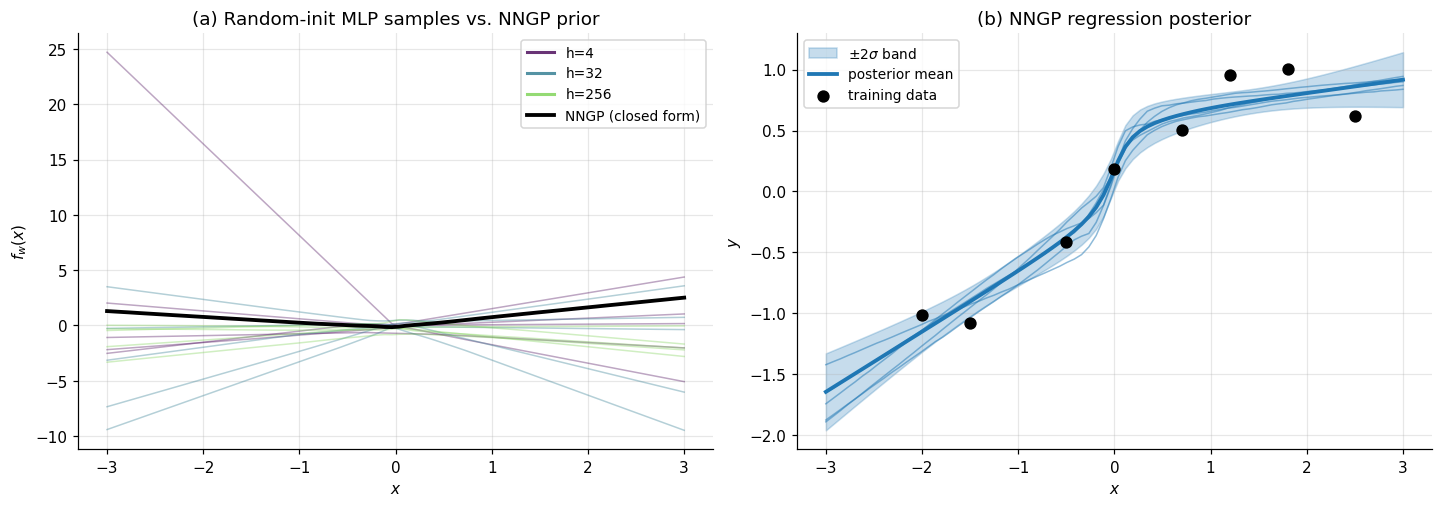

Width convergence — empirical Var[f(0)] vs NNGP K(0,0):
  h=   4: empirical Var = 0.0872
  h=  32: empirical Var = 0.0760
  h= 256: empirical Var = 0.1772
  NNGP : closed-form K(0,0) = 0.1029
§9 cell wall-clock                  : 0.4s


In [10]:
# === §9: NNGP sidebar — infinite-width prior is a GP ===
# (a) random-init MLP samples at three widths converge to NNGP prior
# (b) NNGP regression posterior on a 1D toy dataset

t0 = time.time()

# 1D grid
x_grid = np.linspace(-3, 3, 80, dtype=np.float32)
X1 = x_grid.reshape(-1, 1)
X1_t = torch.from_numpy(X1)

# Cho-Saul arc-cosine recursion for ReLU NNGP kernel (one hidden layer, scaled NTK params)
SIGMA_W2 = 2.0  # standard He-init-style scaling so ReLU NNGP is well-behaved
SIGMA_B2 = 0.05

def nngp_kernel_1layer(X, sigma_w2=SIGMA_W2, sigma_b2=SIGMA_B2):
    """NNGP kernel after one ReLU hidden layer (closed form via arc-cosine kernel)."""
    # Promote to float64: kernel matrix conditioning at n=80 needs >7 digits.
    X = np.asarray(X, dtype=np.float64)
    n = len(X)
    # Pre-activation kernel: k0(x, x') = sigma_b2 + sigma_w2 * <x, x'> / d
    K0 = sigma_b2 + sigma_w2 * (X @ X.T)
    # Arc-cosine kernel for ReLU (Cho & Saul 2009):
    # k1(x,x') = (sigma_b2 + sigma_w2/(2*pi)) * sqrt(K0(x,x)*K0(x',x'))*(sin(theta) + (pi-theta)*cos(theta))
    # where theta = arccos(K0(x,x')/sqrt(K0(x,x)*K0(x',x')))
    diag_K0 = np.diag(K0)
    norm = np.sqrt(np.outer(diag_K0, diag_K0))
    cos_theta = np.clip(K0 / np.maximum(norm, 1e-12), -1.0, 1.0)
    theta = np.arccos(cos_theta)
    K1 = sigma_b2 + (sigma_w2 / (2 * np.pi)) * norm * (np.sin(theta) + (np.pi - theta) * cos_theta)
    return K1

K_nngp = nngp_kernel_1layer(X1)

# (a) Sample random-init MLPs at three widths
def sample_mlp_function(width, sigma_w2=SIGMA_W2, sigma_b2=SIGMA_B2, x_grid=X1, seed=0):
    rng = np.random.default_rng(seed)
    d_in = x_grid.shape[1]
    W1 = rng.normal(0, np.sqrt(sigma_w2 / d_in), size=(d_in, width))
    b1 = rng.normal(0, np.sqrt(sigma_b2),       size=(width,))
    w2 = rng.normal(0, np.sqrt(sigma_w2 / width), size=(width,))
    b2 = rng.normal(0, np.sqrt(sigma_b2))
    h = np.maximum(0, x_grid @ W1 + b1)
    return h @ w2 + b2

widths = [4, 32, 256]
N_SAMPLES_PER_WIDTH = 5
mlp_samples = {}
for w in widths:
    mlp_samples[w] = np.array([sample_mlp_function(w, seed=s) for s in range(N_SAMPLES_PER_WIDTH)])

# Closed-form NNGP prior sample via Cholesky
L_nngp = np.linalg.cholesky(K_nngp + 1e-6 * np.eye(len(X1)))
nngp_sample = L_nngp @ np.random.default_rng(SEED).normal(size=len(X1))

# (b) NNGP regression posterior on a toy 1D problem
np.random.seed(SEED + 7)
X_train = np.array([[-2.0], [-1.5], [-0.5], [0.0], [0.7], [1.2], [1.8], [2.5]], dtype=np.float32)
y_train_nngp = np.sin(X_train.ravel()) + 0.1 * np.random.normal(size=len(X_train))
SIGMA_NOISE = 0.1

K_train      = nngp_kernel_1layer(X_train)
K_train_grid = nngp_kernel_1layer(np.vstack([X_train, X1]))[:len(X_train), len(X_train):]
K_grid       = nngp_kernel_1layer(X1)

# GP regression posterior
A = K_train + SIGMA_NOISE**2 * np.eye(len(X_train))
A_inv_y = np.linalg.solve(A, y_train_nngp)
mu_post  = K_train_grid.T @ A_inv_y
A_inv_K  = np.linalg.solve(A, K_train_grid)
cov_post = K_grid - K_train_grid.T @ A_inv_K
sd_post  = np.sqrt(np.maximum(np.diag(cov_post), 0))

# Posterior samples
np.random.seed(SEED + 8)
L_post = np.linalg.cholesky(cov_post + 1e-6 * np.eye(len(X1)))
post_samples = mu_post[:, None] + L_post @ np.random.normal(size=(len(X1), 5))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

# (a) Width convergence
ax = axes[0]
cmap = plt.cm.viridis
for i, w in enumerate(widths):
    color = cmap(i / (len(widths) - 0.5))
    for s in range(N_SAMPLES_PER_WIDTH):
        ax.plot(x_grid, mlp_samples[w][s], color=color, alpha=0.35, lw=1.0)
    ax.plot([], [], color=color, lw=2, alpha=0.8, label=f'h={w}')
ax.plot(x_grid, nngp_sample, color='black', lw=2.5, label='NNGP (closed form)')
ax.set_title('(a) Random-init MLP samples vs. NNGP prior')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$f_w(x)$')
ax.legend(loc='best', fontsize=9)

# (b) NNGP regression posterior
ax = axes[1]
ax.fill_between(x_grid, mu_post - 2*sd_post, mu_post + 2*sd_post, alpha=0.25, color=COLOR_LAPLACE, label=r'$\pm 2\sigma$ band')
for s in range(post_samples.shape[1]):
    ax.plot(x_grid, post_samples[:, s], color=COLOR_LAPLACE, alpha=0.5, lw=1.0)
ax.plot(x_grid, mu_post, color=COLOR_LAPLACE, lw=2.5, label='posterior mean')
ax.scatter(X_train.ravel(), y_train_nngp, color='black', s=50, zorder=5, label='training data')
ax.set_title('(b) NNGP regression posterior')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.legend(loc='best', fontsize=9)

plt.savefig(os.path.join(FIG_DIR, '09_nngp_sidebar.png'), dpi=150, bbox_inches='tight')
plt.show()

# Verification: empirical variance vs NNGP kernel diagonal
print('Width convergence — empirical Var[f(0)] vs NNGP K(0,0):')
center_idx = len(x_grid) // 2
for w in widths:
    emp_var = mlp_samples[w][:, center_idx].var(ddof=0)
    print(f'  h={w:4d}: empirical Var = {emp_var:.4f}')
print(f'  NNGP : closed-form K(0,0) = {K_nngp[center_idx, center_idx]:.4f}')
print(f'§9 cell wall-clock                  : {time.time()-t0:.1f}s')


## Closing

This notebook developed five recipes for Bayesian neural-network posterior inference (Laplace, MC-dropout, deep ensembles, SGLD, SGHMC), evaluated them head-to-head on calibration metrics on the Two Moons running example, and closed with the function-space view that ties weight-space methods to Gaussian processes via NNGP and NTK. The handoff brief at `docs/plans/formalml-bayesian-neural-networks-handoff-brief.md` is the implementation spec for the MDX site; this notebook is the source of truth for math, code, and figures.

**Reproducibility.** All cells use `SEED = 42`. Total end-to-end runtime is recorded in the brief §12.

**Forward pointers.** Cold-posterior effect (§8.5) and function-space VI (§9.4) connect to planned topics on `sparse-bayesian-priors` and the deeper SG-MCMC variants in `stochastic-gradient-mcmc`. The infinite-width treatment in §9 is intentionally a sidebar — full NNGP/NTK derivations live in the GP track or a future dedicated topic.
